In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


# Plotting time

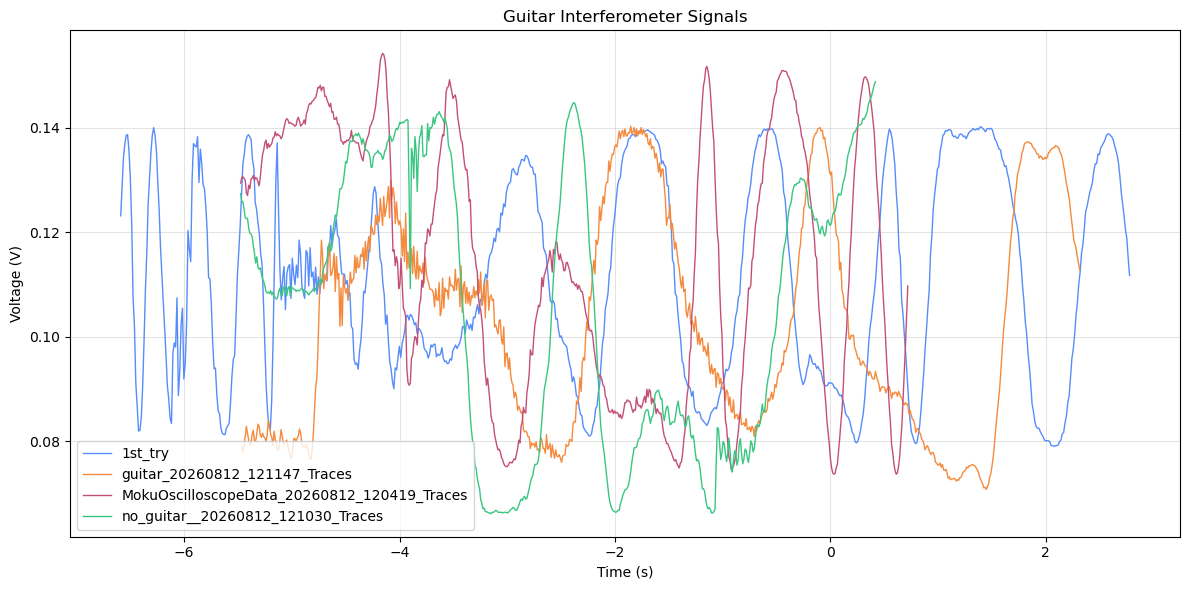

In [41]:


# -----------------------------
# Settings
# -----------------------------
DATA_DIR = Path("data")

# -----------------------------
# Function to load Moku CSV file
# -----------------------------
def load_moku_csv(filepath):

    with open(filepath, "r") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if "Time (s)" in line:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"Could not find data header in {filepath}")

    df = pd.read_csv(filepath, skiprows=header_idx)

    # Rename columns for convenience
    df.columns = [c.strip() for c in df.columns]

    time = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    signal = pd.to_numeric(df.iloc[:, 1], errors="coerce")

    # Remove rows containing NaNs
    valid = np.isfinite(time) & np.isfinite(signal)

    time = time[valid].to_numpy()
    signal = signal[valid].to_numpy()

    return time, signal

# -----------------------------
# Plot all time traces
# -----------------------------
plt.figure(figsize=(12, 6))

for csv_file in sorted(DATA_DIR.glob("*.csv")):
    t, signal = load_moku_csv(csv_file)

    plt.plot(
        t,
        signal,
        label=csv_file.stem,
        linewidth=1
    )

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Guitar Interferometer Signals")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

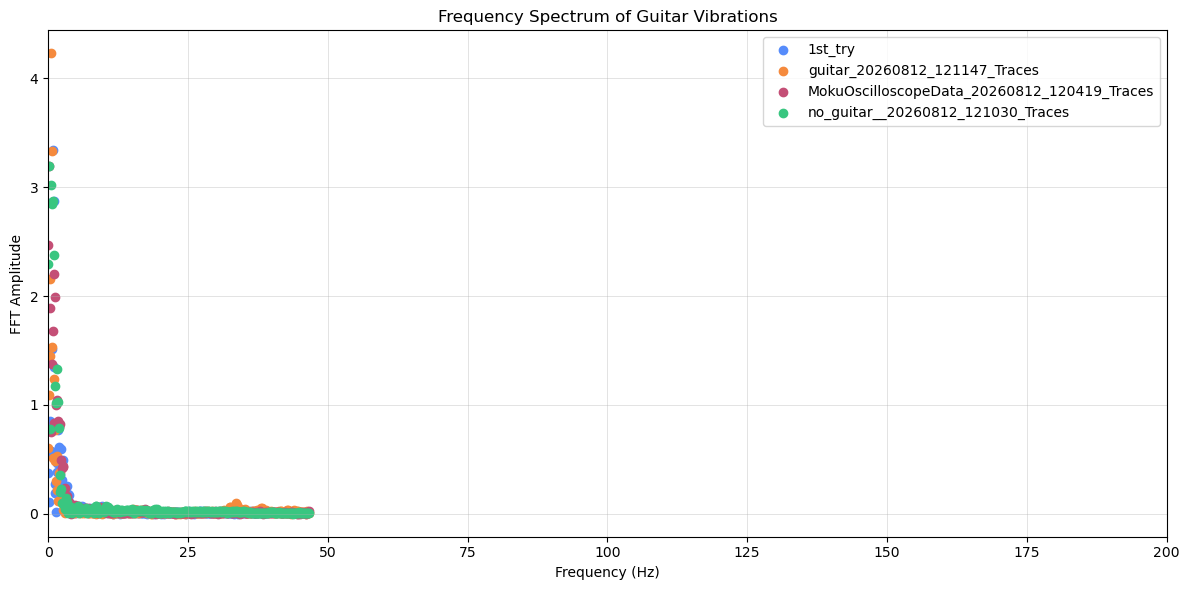

In [44]:

# -----------------------------
# FFT function
# -----------------------------
def compute_fft(t, signal):

    dt = np.mean(np.diff(t))

    N = len(signal)

    # Remove DC offset
    signal = signal - np.mean(signal)

    # Windowing reduces spectral leakage
    window = np.hanning(N)
    signal_windowed = signal * window

    fft_vals = np.fft.rfft(signal_windowed)
    freqs = np.fft.rfftfreq(N, dt)

    amplitude = np.abs(fft_vals)

    return freqs, amplitude


# -----------------------------
# Plot FFT for all files
# -----------------------------
plt.figure(figsize=(12, 6))

for csv_file in sorted(DATA_DIR.glob("*.csv")):

    t, signal = load_moku_csv(csv_file)

    freqs, amplitude = compute_fft(t, signal)

    plt.scatter(
        freqs,
        amplitude,
        label=csv_file.stem
    )
plt.xlim(0,200)
plt.xlabel("Frequency (Hz)")
plt.ylabel("FFT Amplitude")
plt.title("Frequency Spectrum of Guitar Vibrations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
import numpy as np
import pandas as pd

# ----------------------------
# Generate test signal
# ----------------------------

fs = 5000          # Sampling rate (Hz)
duration = 5.0     # Seconds

t = np.arange(-5, duration, 1/fs)

# Guitar-like signal (A string = 110 Hz)
signal = (
    0.05*np.sin(2*np.pi*110*t)
    + 0.02*np.sin(2*np.pi*220*t)
    + 0.10*np.sin(2*np.pi*330*t)
)

signal += 0.02*np.random.randn(len(t))

# Create Channel B just for realism
channel_b = 0.05*np.random.randn(len(t))

# Introduce NaNs
nan_indices = np.random.choice(len(t), size=20, replace=False)
signal[nan_indices] = np.nan

# DataFrame
df = pd.DataFrame({
    "Time (s)": t,
    "Channel A (Input 1) (V)": signal,
    "Channel B (Input 2) (V)": channel_b,
    "Math (Ch A + Ch B) (V)": signal + channel_b
})

# Add one fully empty row
empty_row = pd.DataFrame([[np.nan]*4], columns=df.columns)
df = pd.concat([df.iloc[:1000], empty_row, df.iloc[1000:]], ignore_index=True)

# ----------------------------
# Write Moku-style CSV
# ----------------------------

filename = "old_data/test_guitar.csv"

with open(filename, "w") as f:

    f.write("% Moku:Lab Oscilloscope\n")
    f.write('"% Channel A (Input 1, on), DC"\n')
    f.write('"% Channel B (Input 2, on), DC"\n')
    f.write("% Acquired 2026-08-18 T 12:00:00 +1000\n")
    f.write("% A-string test\n")

    df.to_csv(f, index=False)

print(f"Saved {filename}")

Saved old_data/test_guitar.csv
